# Групповой проект №5. Deep Learning

## Ozon — категория «Мужская одежда»

Данные выгружены из сервиса MPStats

Представляют из себя аналитику продаж товаров на маркетплейсе Ozon


Взят период с 01.01.2025 по 31.12.2025


Таблица содержит **16 столбцов**.

| Столбец | Описание |
|---------|----------|
| Thumb | URL изображения товара |
| Name | Название товара |
| SKU | Идентификатор товара на Ozon |
| Niche | Ниша |
| Brand | Бренд |
| Category | Категория |
| Revenue | Выручка за период отчёта |
| Lost profit | Упущенная прибыль за период |
| Sales | Продажи за период, шт. |
| Balance | Остаток на складах |
| Turnover | Оборачиваемость |
| Frozen stocks percent | Доля замороженного остатка |
| Base price | Базовая цена |
| Rating | Рейтинг товара |
| Comments | Количество отзывов |
| Days in website | Сколько дней товар представлен на площадке |


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data/ozon_mens_clothing_2025.csv', sep=';', encoding='utf-8-sig', decimal=',')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41295796 entries, 0 to 41295795
Data columns (total 16 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Thumb                  str    
 1   Name                   str    
 2   SKU                    int64  
 3   Niche                  str    
 4   Brand                  str    
 5   Category               str    
 6   Revenue                int64  
 7   Lost profit            float64
 8   Sales                  int64  
 9   Balance                int64  
 10  Turnover               float64
 11  Frozen stocks percent  float64
 12  Base price             int64  
 13  Rating                 float64
 14  Comments               int64  
 15  Days in website        int64  
dtypes: float64(4), int64(7), str(5)
memory usage: 4.9 GB


## EDA

In [3]:
print('Размер таблицы:', df.shape)
print('Дубликаты:', df.duplicated('SKU').sum())

Размер таблицы: (41295796, 16)
Дубликаты: 0


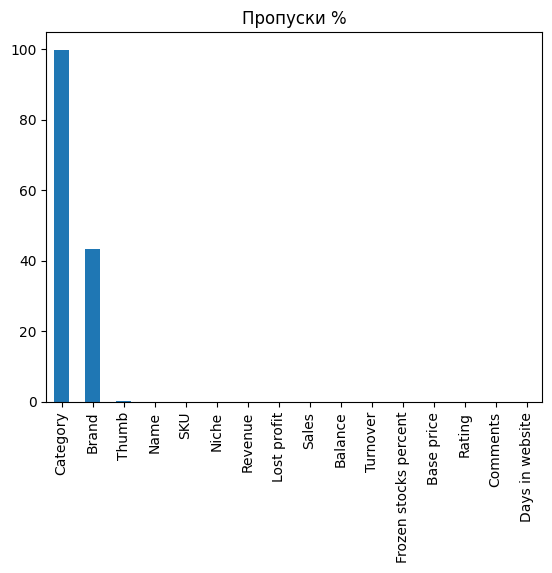

Thumb                     0.100407
Name                      0.000005
SKU                       0.000000
Niche                     0.000000
Brand                    43.320613
Category                 99.865260
Revenue                   0.000000
Lost profit               0.000000
Sales                     0.000000
Balance                   0.000000
Turnover                  0.000000
Frozen stocks percent     0.000000
Base price                0.000000
Rating                    0.000000
Comments                  0.000000
Days in website           0.000000
dtype: float64

In [4]:
import matplotlib.pyplot as plt
percent_missing = df.isna().mean() * 100
percent_missing.sort_values(ascending=False).plot.bar()
plt.title('Пропуски %')
plt.show()
percent_missing

In [5]:
df['Brand'] = df['Brand'].fillna('Unknown')
df = df.drop(columns=['Category'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41295796 entries, 0 to 41295795
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Thumb                  str    
 1   Name                   str    
 2   SKU                    int64  
 3   Niche                  str    
 4   Brand                  str    
 5   Revenue                int64  
 6   Lost profit            float64
 7   Sales                  int64  
 8   Balance                int64  
 9   Turnover               float64
 10  Frozen stocks percent  float64
 11  Base price             int64  
 12  Rating                 float64
 13  Comments               int64  
 14  Days in website        int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 4.6 GB


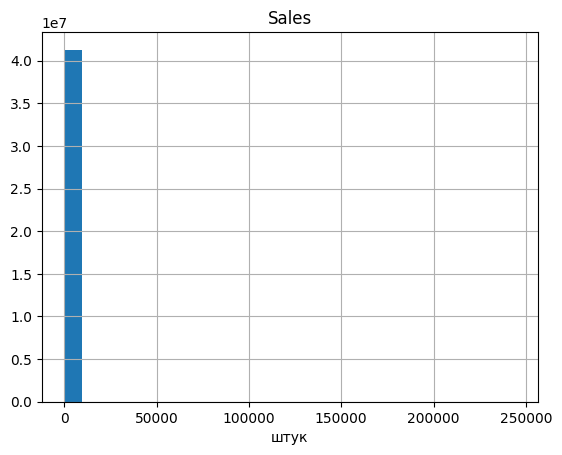

In [6]:
df['Sales'].hist(bins=25)
plt.title('Sales')
plt.xlabel('штук')
plt.show()

In [7]:
zero_sales = (df['Sales'] == 0).sum()
with_sales = (df['Sales'] > 0).sum()
total = len(df)

print('Всего SKU:', total)
print('Без продаж:', zero_sales)
print('С продажами:', with_sales)
print('Доля без продаж:', round(zero_sales / total * 100, 2), "%")
print('Доля с продажами:', round(with_sales / total * 100, 2), "%")

Всего SKU: 41295796
Без продаж: 39532110
С продажами: 1763686
Доля без продаж: 95.73 %
Доля с продажами: 4.27 %


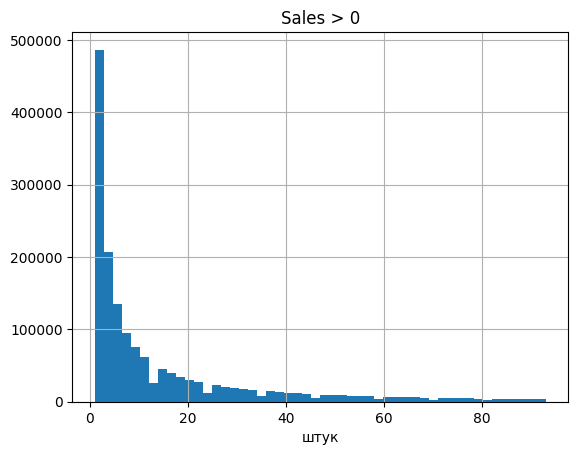

In [8]:
sales_more_then_zero = df.loc[df['Sales'] > 0, 'Sales']
sales_more_then_zero[sales_more_then_zero < sales_more_then_zero.quantile(0.9)].hist(bins=50)
plt.title('Sales > 0')
plt.xlabel('штук')
plt.show()

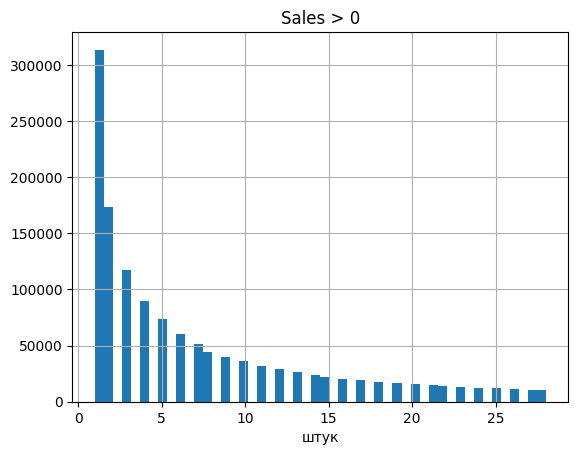

In [9]:
sales_more_then_zero = df.loc[df['Sales'] > 0, 'Sales']
sales_more_then_zero[sales_more_then_zero < sales_more_then_zero.quantile(0.75)].hist(bins=50)
plt.title('Sales > 0')
plt.xlabel('штук')
plt.show()

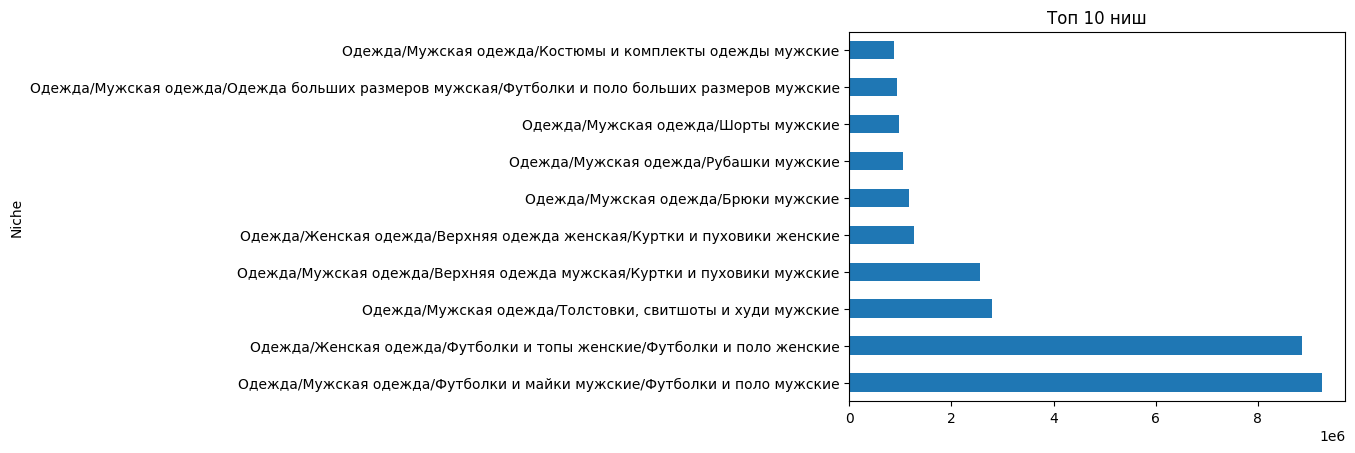

In [10]:
df['Niche'].value_counts().head(10).plot.barh()
plt.title('Топ 10 ниш')
plt.show()

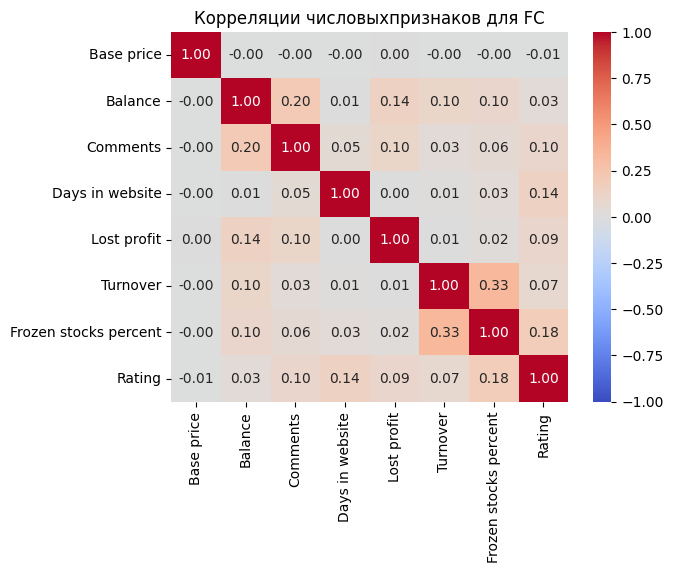

In [11]:
import seaborn as sns

num_features = [
    'Base price', 'Balance', 'Comments', 'Days in website',
    'Lost profit', 'Turnover', 'Frozen stocks percent', 'Rating'
]
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляции числовыхпризнаков для FC')
plt.show()

## Задача A

Какие товары являются лидерами продаж?

Целевая переменная high_sales

Смотрим только на товары с Sales > 0

high_sales = 1, если товар входит в топ 25 процентов по продажам, иначе high_sales = 0
Для товаров Sales = 0 считаем, что high_sales = 0

In [12]:
limit = sales_more_then_zero.quantile(0.75)
df['high_sales'] = (df['Sales'] >= limit).astype(int)

print('Порог Sales для лидера:', limit)
print('Доля лидеров %:', (df['high_sales'].mean() * 100).round(2))
print('Продажи > 0 %:', ((df['Sales'] > 0).mean() * 100).round(2))

Порог Sales для лидера: 29.0
Доля лидеров %: 1.07
Продажи > 0 %: 4.27


In [13]:
features = [
    'Base price', 'Balance', 'Comments', 'Days in website',
    'Lost profit', 'Turnover', 'Frozen stocks percent', 'Rating',
    'Brand', 'Niche',
]
target = 'high_sales'

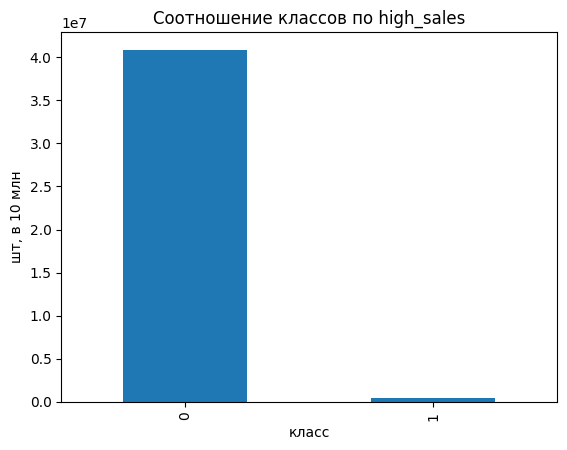

In [14]:
df['high_sales'].value_counts().plot.bar()
plt.title('Соотношение классов по high_sales')
plt.xlabel('класс')
plt.ylabel('шт, в 10 млн')
plt.show()

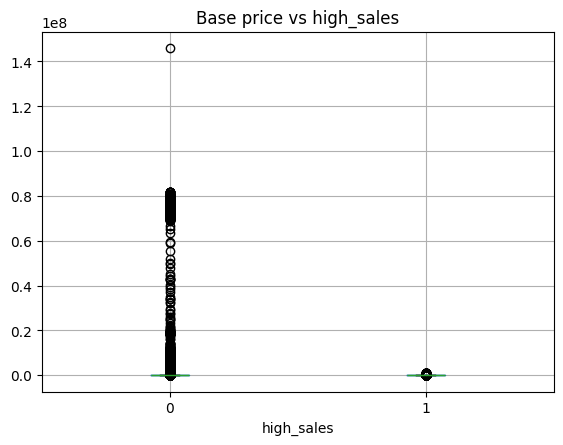

In [15]:
df.boxplot(column='Base price', by='high_sales')
plt.title('Base price vs high_sales')
plt.suptitle('')
plt.show()

## Готовим данные

Лидеров с high_sales = 1 около 1%, поэтому для обучения нужно сделать сбалансированную выборку

Берем всех лидеров с ограничением сверху (в нашем случае 150к) и столько же не лидеров

Числовые признаки стандартизуем, нишу кодируем one-hot - берем топ12 + other

Делим на train и test со стратификацией

In [16]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, roc_auc_score

num_features = ['Base price', 'Balance', 'Comments', 'Days in website', 'Lost profit', 'Turnover', 'Frozen stocks percent', 'Rating']

n = min((df['high_sales'] == 1).sum(), 150000)
liders = df[df['high_sales'] == 1].sample(n, random_state=42)
no_liders = df[df['high_sales'] == 0].sample(n, random_state=42)
data = pd.concat([liders, no_liders]).sample(frac=1, random_state=42)
data.shape

(300000, 16)

In [17]:
top_niche = data['Niche'].value_counts().head(12).index
niche = data['Niche'].where(data['Niche'].isin(top_niche), 'Other')
X_niche = pd.get_dummies(niche)

X = pd.concat([data[num_features].fillna(0).reset_index(drop=True), X_niche.reset_index(drop=True)], axis=1)
y = data['high_sales'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds = torch.utils.data.TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
input_count = X_train.shape[1]

print('train:', len(train_ds))
print('test:', len(test_ds))

train: 240000
test: 60000


## Сравниваем три конфигурации

In [18]:
from pathlib import Path
import wandb
WANDB_KEY = Path('wandb.key').read_text().strip()

In [19]:
import os
import random

def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

## взяли из семинара, потому что wandb хочет словарь
def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))


## это взято отсюда https://stackoverflow.com/questions/48152674/how-do-i-check-if-pytorch-is-using-the-gpu
device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')


class CFG:
    api = WANDB_KEY
    entity = ''
    project = 'ozon_fc'
    seed = 42
    epochs = 15
    batch_size = 1024
    lr = 0.001
    hidden = [128, 64]
    dropout = 0.0
    optimizer = 'adam'
    name = 'fc'


def build_model(input_count, hidden, dropout):
    layers, prev = [], input_count
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, 2))
    return nn.Sequential(*layers)

In [20]:
## код для train и validate был взят отсюда https://stackoverflow.com/questions/67295494/correct-validation-loss-in-pytorch и переделан под нашу задачу 

def train(model, loader, optimizer, criterion):
    model.train()
    correct = 0                                                                          
    running_loss = 0.0    
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(yb)
        correct += (outputs.argmax(1) == yb).sum().item()
        total += len(yb)
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    running_loss = 0.0    
    total = 0
    model.eval()
    true_ans = []
    preds = []
    probs = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        outputs = model(xb)

        running_loss += criterion(outputs, yb).item() * len(yb)
        total += len(yb)
        
        true_ans += yb.cpu().tolist()
        preds += outputs.argmax(1).cpu().tolist()
        probs += outputs.softmax(1)[:, 1].cpu().tolist()
    acc = accuracy_score(true_ans, preds)
    return running_loss / total, acc, true_ans, preds, probs


def run_fc(cfg):
    seed_everything(cfg.seed)
    os.environ["WANDB_API_KEY"] = CFG.api
    wandb.init(project=CFG.project, entity=CFG.entity, reinit=True, config=class2dict(CFG))

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=cfg.batch_size)
    model = build_model(input_count, cfg.hidden, cfg.dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    if cfg.optimizer == 'adam':
        opt_cls = torch.optim.Adam
    else:
        opt_cls = torch.optim.SGD
    optimizer = opt_cls(model.parameters(), lr=cfg.lr)

    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion)
        test_loss, test_acc, true_ans, preds, probs = validate(model, test_loader, criterion)
        wandb.log({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'test_loss': test_loss, 'test_acc': test_acc})

    metrics = {'accuracy': accuracy_score(true_ans, preds),
               'precision': precision_score(true_ans, preds),
               'recall': recall_score(true_ans, preds),
               'f1': f1_score(true_ans, preds),
               'roc_auc': roc_auc_score(true_ans, probs)}

    wandb.log(metrics)
    path = f'{cfg.name}.pt'
    torch.save(model.state_dict(), path)
    wandb.save(path)
    wandb.finish()
    return metrics

## Настройки конфиграций

In [21]:
results_fc = {}

cfg = CFG()
cfg.name = 'fc_shallow'
cfg.hidden = [64]
results_fc['shallow'] = run_fc(cfg)

cfg = CFG()
cfg.name = 'fc_deep'
cfg.hidden = [256, 128, 64]
results_fc['deep'] = run_fc(cfg)

cfg = CFG()
cfg.name = 'fc_deep_dropout_sgd'
cfg.hidden = [256, 128, 64]
cfg.dropout = 0.3
cfg.optimizer = 'sgd'
cfg.lr = 0.05
results_fc['deep_dropout_sgd'] = run_fc(cfg)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: mooninvader (mooninvader-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


accuracy,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
f1,▁
precision,▁
recall,▁
roc_auc,▁
test_acc,▁▄▅▆▇▇▇████████
test_loss,█▆▅▄▃▃▃▂▂▂▁▁▁▁▁
train_acc,▁▅▆▇▇▇█████████
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁
accuracy,0.97975


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


accuracy,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
f1,▁
precision,▁
recall,▁
roc_auc,▁
test_acc,▁▄▅▆▅▇▅▆▇▆▆▆▇▇█
test_loss,█▅▃▃▃▂▃▂▂▃▃▂▂▂▁
train_acc,▁▆▇▇▇██████████
train_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁
accuracy,0.9836


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


accuracy,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
f1,▁
precision,▁
recall,▁
roc_auc,▁
test_acc,▁▃▃▄▅▅▆▆▆▇▇▇███
test_loss,█▆▆▅▄▃▃▃▃▂▂▂▁▁▁
train_acc,▁▅▅▆▆▆▇▇▇▇▇████
train_loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁
accuracy,0.9701


                     f1  roc_auc  accuracy
shallow           0.980    0.995     0.980
deep              0.984    0.996     0.984
deep_dropout_sgd  0.970    0.992     0.970


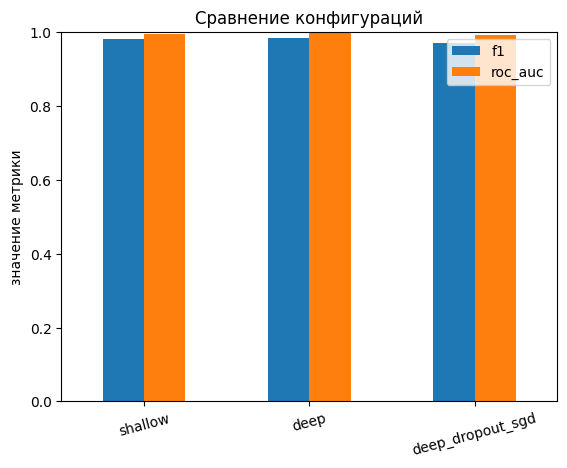

In [61]:
res = pd.DataFrame.from_dict(results_fc, orient='index')[['f1', 'roc_auc', 'accuracy']]
print(res.round(3))

res[['f1', 'roc_auc']].plot.bar()
plt.title('Сравнение конфигураций')
plt.ylabel('значение метрики')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

## Задача B

Обрабатываем изображения и готовим данные

Для классификации ниши по фото берём топ-ниши и сбалансированную выборку карточек
Делим на train и test

In [23]:
idx = pd.read_csv('data/cnn_index.csv')

idx['path'] = 'data/images/' + idx['SKU'].astype(str) + '.jpg'
idx = idx[idx['path'].map(os.path.exists)].reset_index(drop=True)

classes = sorted(idx['Niche'].unique())
classWithId = {}
for i in range(len(classes)):
    classWithId[classes[i]] = i
idx['label'] = idx['Niche'].map(classWithId)
n_classes = len(classes)

img_train, img_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=idx['label'])
print('Число картинок:', len(idx))
print('Число классов:', n_classes)
print('train:', len(img_train), 'test:', len(img_test))
print(idx['Niche'].value_counts())

Число картинок: 23776
Число классов: 7
train: 19020 test: 4756
Niche
Рубашки мужские                       3749
Куртки и пуховики мужские             3748
Брюки мужские                         3748
Футболки и поло женские               3747
Толстовки, свитшоты и худи мужские    3747
Футболки и поло мужские               3425
Джинсы мужские                        1612
Name: count, dtype: int64


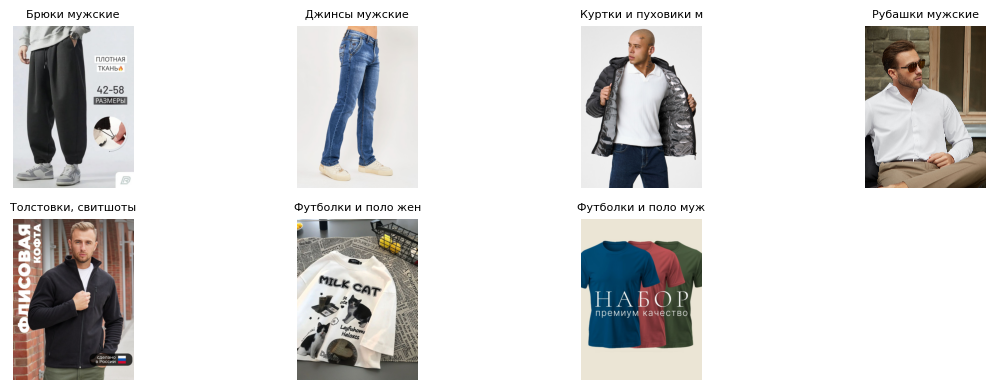

In [26]:
from PIL import Image

sample = idx.groupby('Niche').first().reset_index().head(8)
plt.figure(figsize=(12, 4))
for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row['path']).convert('RGB'))
    plt.title(row['Niche'][:19], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Сравниваем 3 архитектуры

Сравниваем три модели на одних и тех же картинках

**FC-baseline**

**LeNet CNN**

**Deep CNN**


In [28]:
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

tfm = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class OzonImages(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), int(row['label'])


train_img = OzonImages(img_train, tfm)
test_img = OzonImages(img_test, tfm)
print('train картинок:', len(train_img))
print('test картинок:', len(test_img))

train картинок: 19020
test картинок: 4756


In [31]:
class FCBaseline(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n))

    def forward(self, x):
        return self.net(x)

class LeNetCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 13 * 13, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, n)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DeepCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n))

    def forward(self, x):
        return self.classifier(self.features(x))

class CFG_IMG:
    api = WANDB_KEY
    entity = ''
    project = 'ozon_cnn'
    seed = 42
    epochs = 8
    batch_size = 128
    lr = 0.001
    name = 'cnn'

def run_cnn(model, cfg):
    seed_everything(cfg.seed)
    model = model.to(device)

    train_loader = DataLoader(train_img, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_img, batch_size=cfg.batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    os.environ['WANDB_API_KEY'] = cfg.api
    wandb.init(project=cfg.project, entity=cfg.entity or None,
               name=cfg.name, reinit=True, config=class2dict(cfg))

    history = []
    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion)
        test_loss, test_acc, _, _, _ = validate(model, test_loader, criterion)

        history.append({
            'epoch': epoch,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'train_loss': train_loss,
            'test_loss': test_loss,
        })
        wandb.log({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
        })
        print(f'{cfg.name} ep{epoch}: train_acc={train_acc:.3f} test_acc={test_acc:.3f}')

    path = f'{cfg.name}.pt'
    torch.save(model.state_dict(), path)
    wandb.save(path)
    wandb.finish()
    return pd.DataFrame(history)

In [32]:
history_cnn = {}

cfg = CFG_IMG()
cfg.name = 'img_fc_baseline'
history_cnn['fc_baseline'] = run_cnn(FCBaseline(n_classes), cfg)

cfg = CFG_IMG()
cfg.name = 'img_lenet'
history_cnn['lenet'] = run_cnn(LeNetCNN(n_classes), cfg)

cfg = CFG_IMG()
cfg.name = 'img_deepcnn'
history_cnn['deep_cnn'] = run_cnn(DeepCNN(n_classes), cfg)

img_fc_baseline ep1: train_acc=0.563 test_acc=0.654
img_fc_baseline ep2: train_acc=0.735 test_acc=0.738
img_fc_baseline ep3: train_acc=0.825 test_acc=0.823
img_fc_baseline ep4: train_acc=0.873 test_acc=0.836
img_fc_baseline ep5: train_acc=0.897 test_acc=0.837
img_fc_baseline ep6: train_acc=0.912 test_acc=0.874
img_fc_baseline ep7: train_acc=0.931 test_acc=0.895


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


img_fc_baseline ep8: train_acc=0.946 test_acc=0.905


epoch,▁▂▃▄▅▆▇█
test_acc,▁▃▆▆▆▇██
test_loss,█▅▃▃▃▂▁▁
train_acc,▁▄▆▇▇▇██
train_loss,█▅▃▂▂▂▁▁
epoch,8
test_acc,0.90475
test_loss,0.35162
train_acc,0.94553
train_loss,0.16418


img_lenet ep1: train_acc=0.514 test_acc=0.608
img_lenet ep2: train_acc=0.692 test_acc=0.705
img_lenet ep3: train_acc=0.804 test_acc=0.830
img_lenet ep4: train_acc=0.886 test_acc=0.873
img_lenet ep5: train_acc=0.935 test_acc=0.904
img_lenet ep6: train_acc=0.960 test_acc=0.924
img_lenet ep7: train_acc=0.977 test_acc=0.913


...

epoch,▁▂▃▄▅▆▇█
test_acc,▁▃▆▇████
test_loss,█▆▃▂▁▁▂▁
train_acc,▁▄▅▇▇███
train_loss,█▆▄▃▂▁▁▁
epoch,8
test_acc,0.92557
test_loss,0.336
train_acc,0.98291
train_loss,0.05643


img_deepcnn ep1: train_acc=0.532 test_acc=0.685
img_deepcnn ep2: train_acc=0.739 test_acc=0.817
img_deepcnn ep3: train_acc=0.847 test_acc=0.894
img_deepcnn ep4: train_acc=0.909 test_acc=0.927
img_deepcnn ep5: train_acc=0.944 test_acc=0.938
img_deepcnn ep6: train_acc=0.963 test_acc=0.944
img_deepcnn ep7: train_acc=0.971 test_acc=0.949


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


img_deepcnn ep8: train_acc=0.976 test_acc=0.956


epoch,▁▂▃▄▅▆▇█
test_acc,▁▄▆▇████
test_loss,█▄▂▂▁▁▁▁
train_acc,▁▄▆▇▇███
train_loss,█▅▃▂▂▁▁▁
epoch,8
test_acc,0.95606
test_loss,0.21118
train_acc,0.97634
train_loss,0.06844


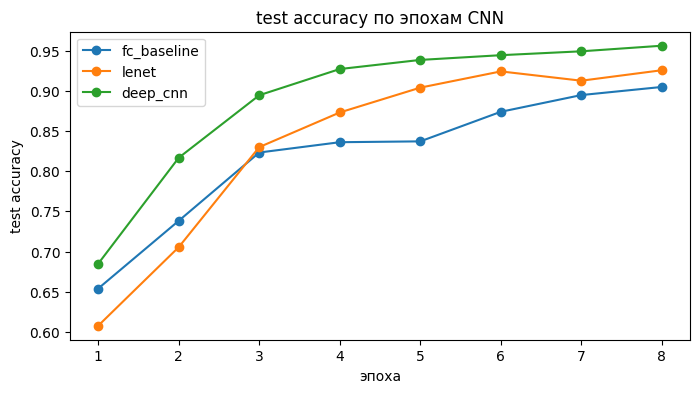

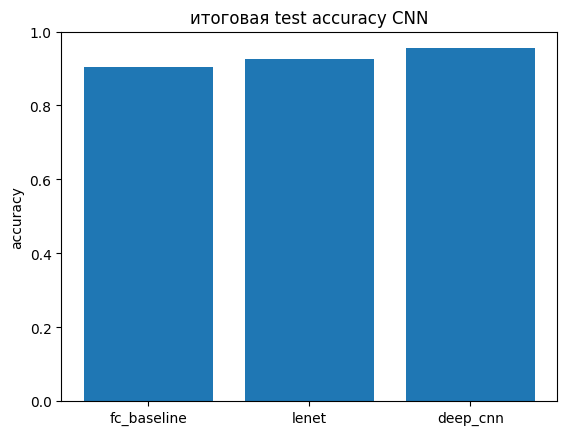

In [34]:
plt.figure(figsize=(8, 4))
for name, h in history_cnn.items():
    plt.plot(h['epoch'], h['test_acc'], marker='o', label=name)
plt.title('test accuracy по эпохам CNN')
plt.xlabel('эпоха')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

final = {}
for name in history_cnn:
    h = history_cnn[name]
    final[name] = h['test_acc'].iloc[-1]
plt.bar(list(final), list(final.values()))
plt.title('итоговая test accuracy CNN')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.show()